1. ARMA(p, q)模型定义

ARMA 模型由两个参数 $p$ 和 $q$ 定义：
- p：自回归部分的阶数，即前几期的值对当前值的影响。
- q：滑动平均部分的阶数，即前几期的误差对当前值的影响。
ARMA 模型的数学形式为：
$$Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$$
其中：
- $Y_t$ 是时间 $t$ 的观测值。
- $c$ 是常数项。
- $\phi_i$ 是自回归部分的系数。
- $\theta_j$ 是滑动平均部分的系数。
- $\epsilon_t$ 是白噪声（随机误差），假设其均值为0，方差为$\sigma^2$。

2. AR部分推导（自回归模型）

自回归（AR）部分表示当前的观测值 $Y_t$ 由前 $p$ 个时刻的观测值通过线性组合得到。
假设我们有一个 $AR(p)$ 模型：
$$Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \epsilon_t$$
即：
- $Y_t$ 是当前的观测值；
- 它受 $p$ 个过去观测值的线性组合影响，系数为 $\phi_i$；
- $\epsilon_t$ 是随机误差（白噪声）。

3. MA部分推导（滑动平均模型）

滑动平均（MA）部分表示当前的观测值 $Y_t$ 由当前和前 $q$ 个时刻的误差通过线性组合得到。
假设我们有一个 $MA(q)$ 模型：
$$Y_t = c + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}$$
即：
- $Y_t$ 是当前的观测值；
- 它由当前误差和前 $q$ 个时刻的误差线性组合得到；
- 系数为 $\theta_j$。

Date
2023-10-26     39.98
2023-06-12    109.42
2023-05-25     50.25
2023-12-17    104.18
2023-10-09     18.23
Name: PM2.5, dtype: float64


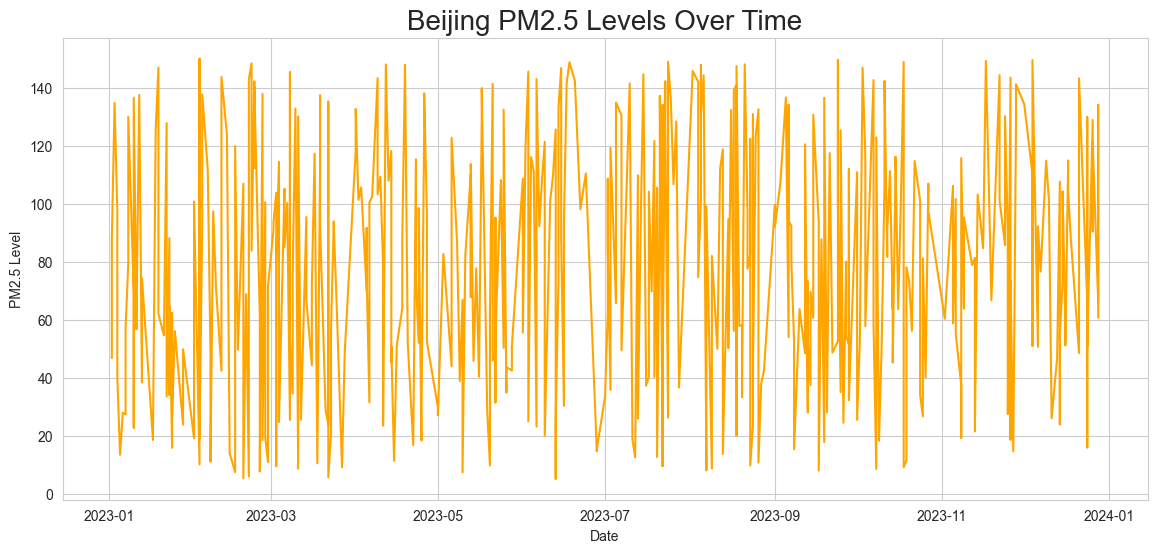

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')

data = pd.read_csv('./Dataset/3.global_air_quality_data_bj.csv')

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

city_data = data[data['City'] == 'Beijing']
pm_data = city_data['PM2.5'].ffill()
print(pm_data.head())
pm_data = pm_data.sort_index()

plt.figure(figsize=(14, 6))
plt.plot(pm_data, color='orange')
plt.title('Beijing PM2.5 Levels Over Time', fontsize=20)
plt.xlabel('Date')
plt.ylabel('PM2.5 Level')
plt.show()

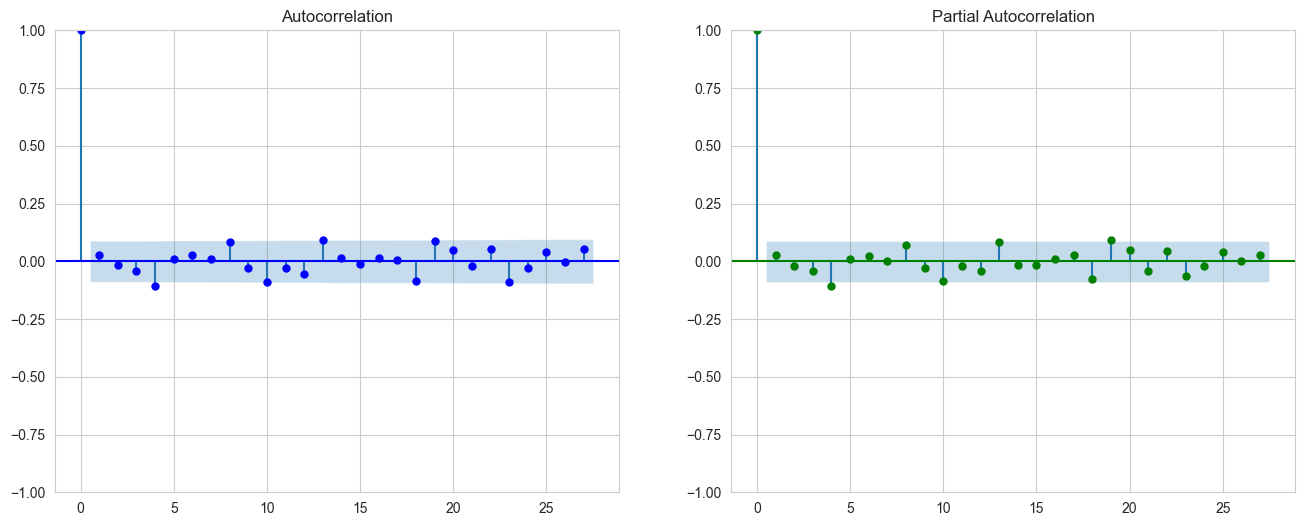

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(pm_data, ax=axes[0], color='blue', title='Autocorrelation')
plot_pacf(pm_data, ax=axes[1], color='green', title='Partial Autocorrelation')
plt.show()

In [3]:
train_data = pm_data[:-100]
test_data = pm_data[-100:]

model = ARIMA(train_data, order=(2, 0, 2))  # ARMA(2, 2)模型
arma_model = model.fit()

print(arma_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                  388
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -2009.379
Date:                Fri, 11 Sep 2026   AIC                           4030.759
Time:                        21:28:45   BIC                           4054.525
Sample:                             0   HQIC                          4040.181
                                - 388                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         77.0733      2.156     35.753      0.000      72.848      81.298
ar.L1          1.1621      0.059     19.833      0.000       1.047       1.277
ar.L2         -0.9340      0.054    -17.281      0.0

D:\code\LearningProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\code\LearningProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\code\LearningProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


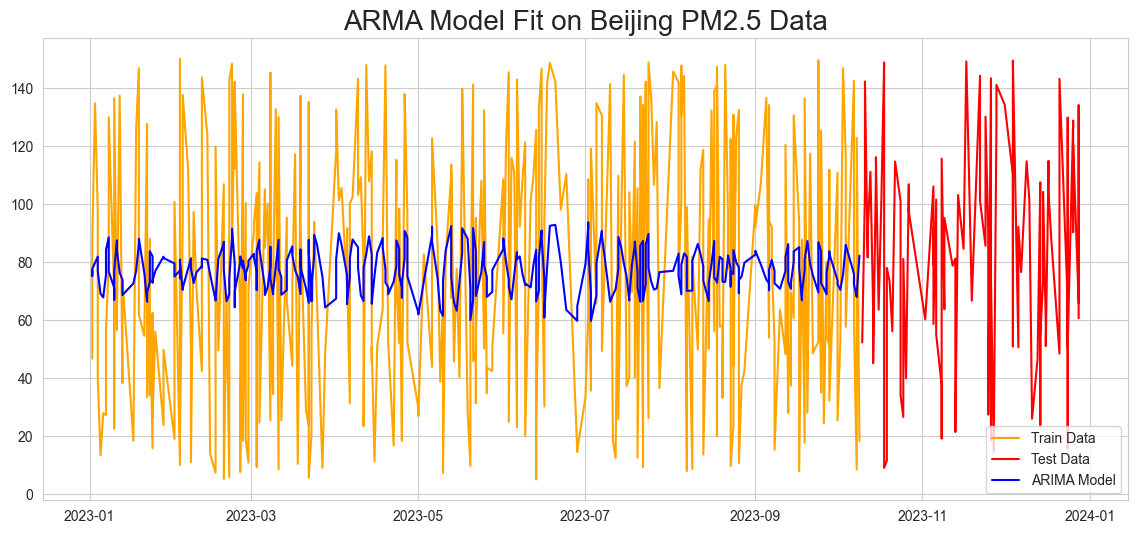

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(train_data, label='Train Data', color='orange')
plt.plot(test_data, label='Test Data', color='red')
plt.plot(arma_model.fittedvalues, label='ARIMA Model', color='blue')
plt.title('ARMA Model Fit on Beijing PM2.5 Data', fontsize=20)
plt.legend()
plt.show()

In [5]:
predictions = arma_model.get_forecast(steps=100)
pred_ci = predictions.conf_int()
predicted_pm = predictions.predicted_mean

fig = go.Figure()
fig.add_trace(go.Scatter(x=pm_data.index, y=pm_data, mode='lines', name='Actual PM2.5 Levels', line=dict(color='purple')))
fig.add_trace(go.Scatter(x=predicted_pm.index, y=predicted_pm, mode='lines', name='Forecasted PM2.5 Levels', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=pred_ci.index, y=pred_ci.iloc[:, 0], fill=None, mode='lines', line=dict(color='lightblue'), name='Lower Confidence Interval'))
fig.add_trace(go.Scatter(x=pred_ci.index, y=pred_ci.iloc[:, 1], fill='tonexty', mode='lines', line=dict(color='lightblue'), name='Upper Confidence Interval'))
fig.update_layout(title="Beijing PM2.5 Levels Forecast with ARMA Model",
                  xaxis_title="Date",
                  yaxis_title="PM2.5 Level",
                  template="plotly_dark")
fig.show()

D:\code\LearningProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\code\LearningProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


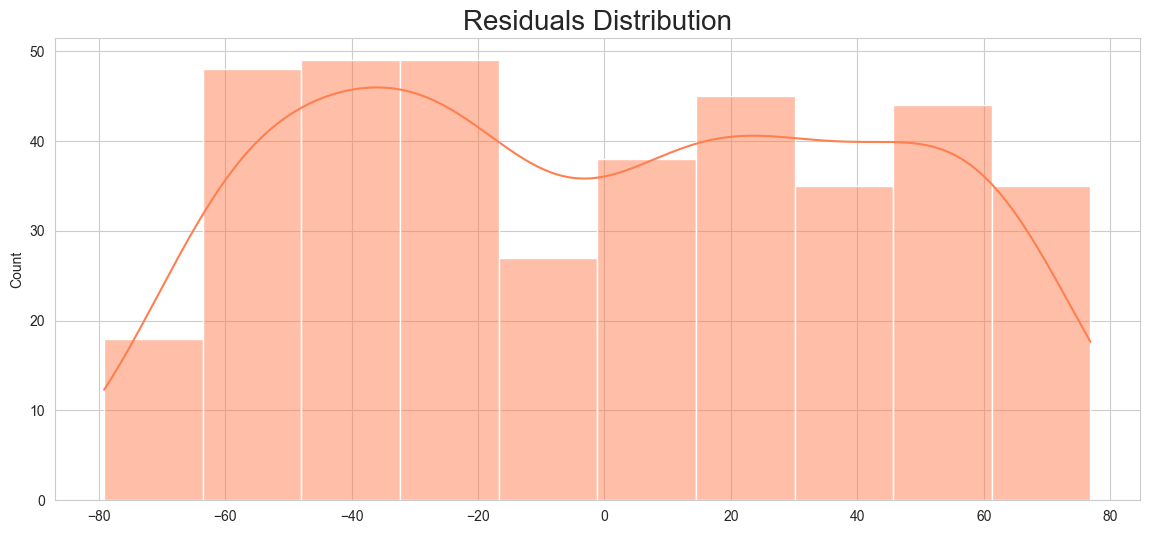

In [6]:
# 残差分析
residuals = arma_model.resid

# 绘制残差的直方图
plt.figure(figsize=(14, 6))
sns.histplot(residuals, kde=True, color='coral')
plt.title("Residuals Distribution", fontsize=20)
plt.show()

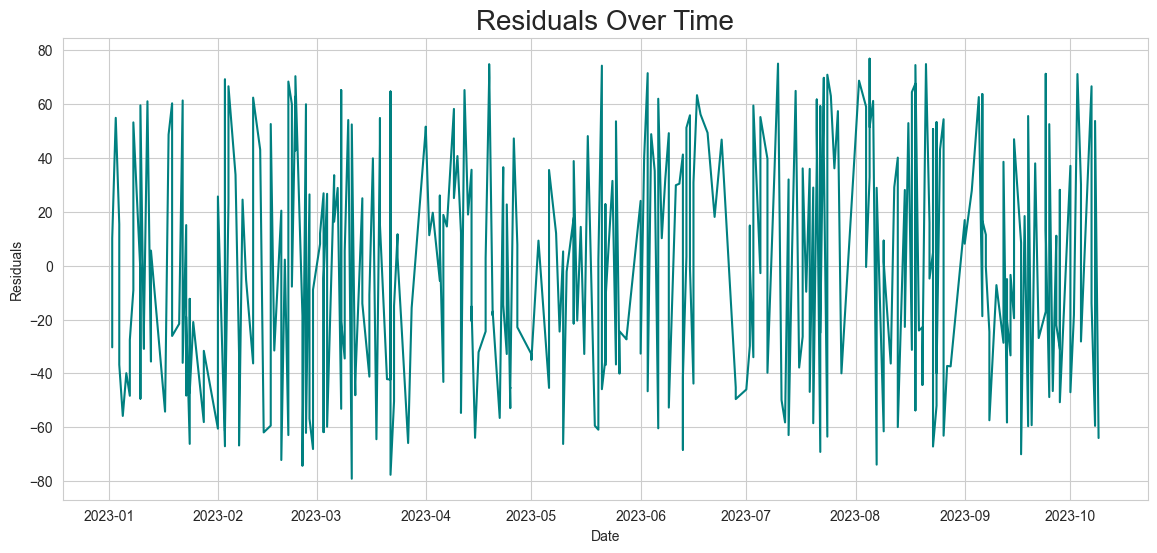

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(residuals, color='teal')
plt.title("Residuals Over Time", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

In [8]:
mse = mean_squared_error(test_data, predicted_pm[:len(test_data)])
print(f"Mean Squared Error of Predictions: {mse:.2f}")

Mean Squared Error of Predictions: 1400.47
